In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. CHARGEMENT DES DONNÉES
df = pd.read_csv('../data/clean_data.csv', encoding='ISO-8859-1')

In [4]:

#  CRÉER LA COLONNE REVENUE
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(df.columns.tolist())
print(f" Revenue créée ! Exemple : {df['Revenue'].head(3).tolist()}")


['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'CA', 'Mois', 'Jour', 'Heure', 'Revenue']
 Revenue créée ! Exemple : [15.299999999999999, 20.34, 22.0]


In [5]:
# KPI : MARKETING 

# Revenu total par pays
revenu_pays = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

# Top 10 pays
top10_pays = revenu_pays.head(10)

print(" TOP 10 PAYS PAR REVENU")
for i, (pays, rev) in enumerate(top10_pays.items(), 1):
    print(f"{i}. {pays}: £{rev:,.0f}")

# Part du UK vs reste du monde
uk_revenue = revenu_pays.get('United Kingdom', 0)
total_revenue = revenu_pays.sum()
autres_revenue = total_revenue - uk_revenue

print(f"\n RÉPARTITION :")
print(f"🇬🇧 UK : £{uk_revenue:,.0f} ({uk_revenue/total_revenue*100:.1f}%)")
print(f" Autres : £{autres_revenue:,.0f} ({autres_revenue/total_revenue*100:.1f}%)")


 TOP 10 PAYS PAR REVENU
1. United Kingdom: £7,285,025
2. Netherlands: £285,446
3. EIRE: £265,262
4. Germany: £228,678
5. France: £208,934
6. Australia: £138,454
7. Spain: £61,559
8. Switzerland: £56,444
9. Belgium: £41,196
10. Sweden: £38,368

 RÉPARTITION :
🇬🇧 UK : £7,285,025 (82.0%)
 Autres : £1,602,184 (18.0%)


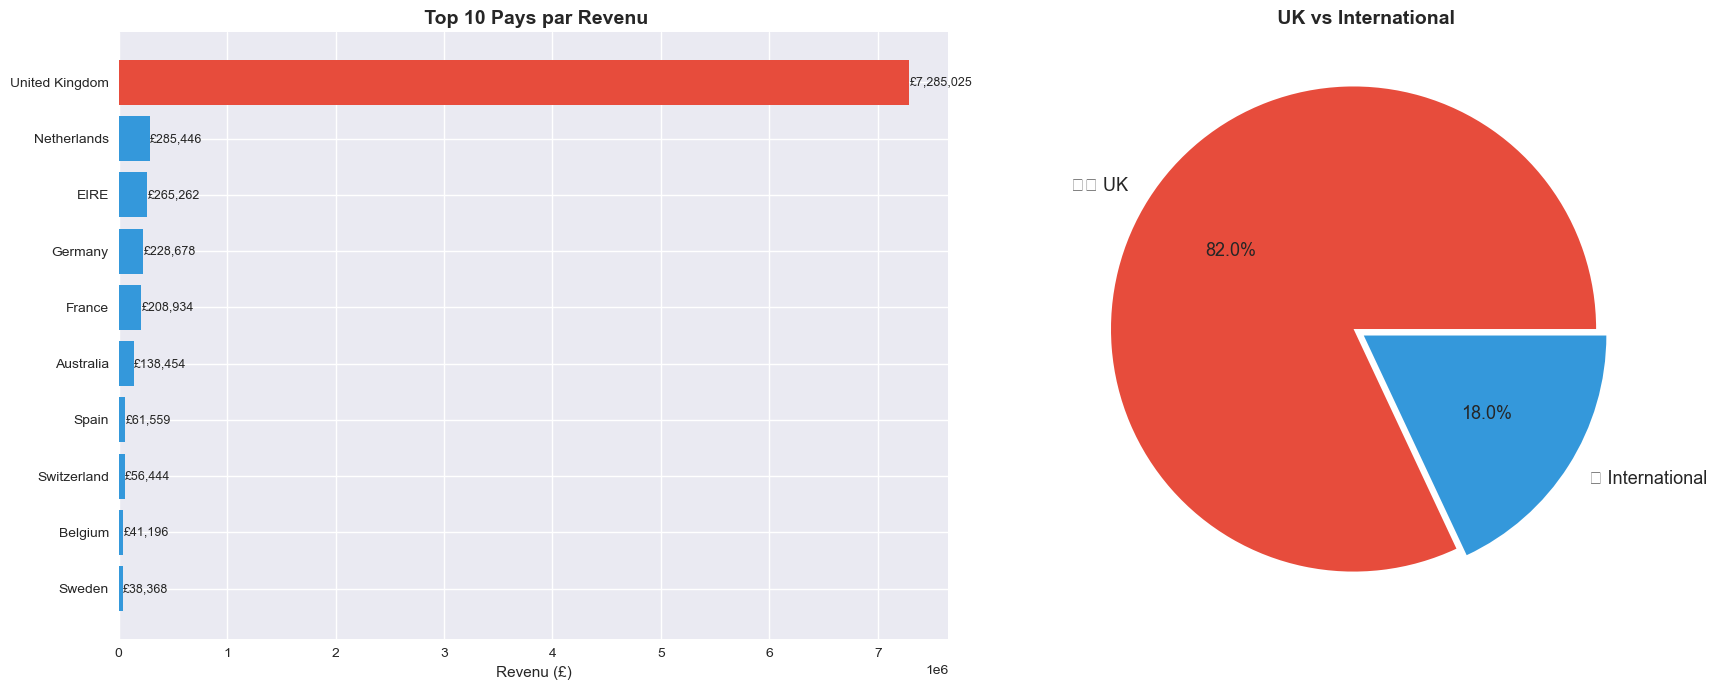

In [9]:
#  GRAPHIQUE TOP 10 PAYS

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart Top 10
colors = ['#e74c3c' if p == 'United Kingdom' else '#3498db' for p in top10_pays.index]
axes[0].barh(top10_pays.index[::-1], top10_pays.values[::-1], color=colors[::-1])
axes[0].set_title(' Top 10 Pays par Revenu', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Revenu (£)')

for i, v in enumerate(top10_pays.values[::-1]):
    axes[0].text(v + 5000, i, f'£{v:,.0f}', va='center', fontsize=9)

# Pie chart UK vs Monde
axes[1].pie([uk_revenue, autres_revenue], 
            labels=['🇬🇧 UK', '🌍 International'],
            autopct='%1.1f%%', 
            colors=['#e74c3c', '#3498db'],
            explode=(0.05, 0),
            textprops={'fontsize': 13})
axes[1].set_title(' UK vs International', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [12]:
# ETAPE 2 : TOP PRODUITS
# Top 10 produits par revenu
top_produits_rev = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

# Top 10 produits par quantité vendue
top_produits_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

print("TOP 10 PRODUITS PAR REVENU")
for i, (prod, rev) in enumerate(top_produits_rev.items(), 1):
    print(f"{i}. {prod}: £{rev:,.0f}")

print(f"\n TOP 10 PRODUITS PAR QUANTITÉ")
for i, (prod, qty) in enumerate(top_produits_qty.items(), 1):
    print(f"{i}. {prod}: {qty:,.0f} unités")


TOP 10 PRODUITS PAR REVENU
1. PAPER CRAFT , LITTLE BIRDIE: £168,470
2. REGENCY CAKESTAND 3 TIER: £142,265
3. WHITE HANGING HEART T-LIGHT HOLDER: £100,392
4. JUMBO BAG RED RETROSPOT: £85,041
5. MEDIUM CERAMIC TOP STORAGE JAR: £81,417
6. POSTAGE: £77,804
7. PARTY BUNTING: £68,785
8. ASSORTED COLOUR BIRD ORNAMENT: £56,413
9. Manual: £53,420
10. RABBIT NIGHT LIGHT: £51,251

 TOP 10 PRODUITS PAR QUANTITÉ
1. PAPER CRAFT , LITTLE BIRDIE: 80,995 unités
2. MEDIUM CERAMIC TOP STORAGE JAR: 77,916 unités
3. WORLD WAR 2 GLIDERS ASSTD DESIGNS: 54,319 unités
4. JUMBO BAG RED RETROSPOT: 46,078 unités
5. WHITE HANGING HEART T-LIGHT HOLDER: 36,706 unités
6. ASSORTED COLOUR BIRD ORNAMENT: 35,263 unités
7. PACK OF 72 RETROSPOT CAKE CASES: 33,670 unités
8. POPCORN HOLDER: 30,919 unités
9. RABBIT NIGHT LIGHT: 27,153 unités
10. MINI PAINT SET VINTAGE : 26,076 unités


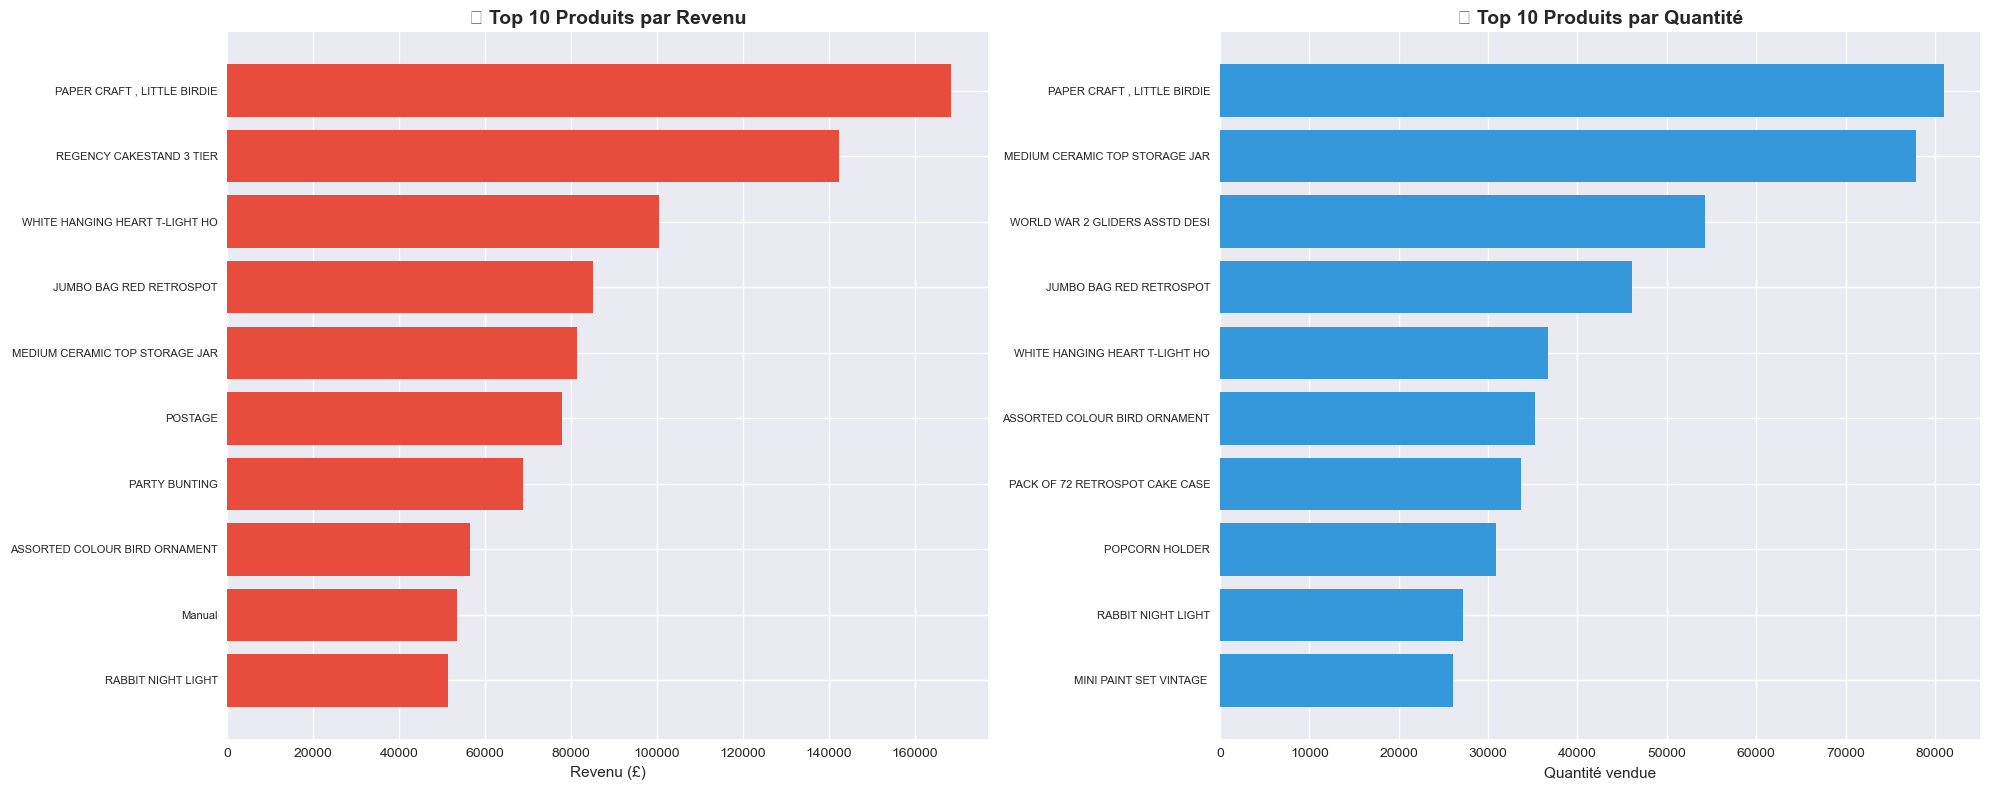

In [13]:
#  GRAPHIQUE TOP PRODUITS

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Top par revenu
axes[0].barh(range(10), top_produits_rev.values[::-1], color='#e74c3c')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([p[:30] for p in top_produits_rev.index[::-1]], fontsize=8)
axes[0].set_title('💰 Top 10 Produits par Revenu', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Revenu (£)')

# Top par quantité
axes[1].barh(range(10), top_produits_qty.values[::-1], color='#3498db')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([p[:30] for p in top_produits_qty.index[::-1]], fontsize=8)
axes[1].set_title('📦 Top 10 Produits par Quantité', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quantité vendue')

plt.tight_layout()
plt.show()
